In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/72_unsharp_clahe_augmented_6.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/49_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/57_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/97_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/60_unsharp_clahe_augmented_4.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/100_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/26_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/74_unsharp_clahe_augmented_0.png
/kaggle/input/datasets/

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [13]:
base_dir = '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset' 

train_dir = os.path.join(base_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/train')
val_dir = os.path.join(base_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val')
test_dir = os.path.join(base_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/test')


In [14]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [15]:
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val_test'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val_test'])

class_names = train_dataset.classes
print(f"Detected classes: {class_names}")

Detected classes: ['Anthracnose', 'fruit_fly', 'healthy_guava']


In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [17]:
model = models.alexnet(weights='DEFAULT')
print("Pretrained AlexNet loaded.")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 227MB/s] 


Pretrained AlexNet loaded.


In [18]:
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 3) 

print("Classifier modified for 3 classes.")

Classifier modified for 3 classes.


In [19]:
model = model.to(device)

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [21]:
epochs = 10

for epoch in range(epochs):
    # Training 
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Validation 
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            
    val_acc = val_corrects.double() / len(val_loader.dataset)
    
    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}')

Epoch 1/10 | Train Loss: 0.1478 | Val Acc: 0.9894
Epoch 2/10 | Train Loss: 0.0396 | Val Acc: 0.9921
Epoch 3/10 | Train Loss: 0.0274 | Val Acc: 0.9894
Epoch 4/10 | Train Loss: 0.0152 | Val Acc: 0.9934
Epoch 5/10 | Train Loss: 0.0085 | Val Acc: 0.9947
Epoch 6/10 | Train Loss: 0.0136 | Val Acc: 0.9934
Epoch 7/10 | Train Loss: 0.0063 | Val Acc: 0.9960
Epoch 8/10 | Train Loss: 0.0179 | Val Acc: 0.9947
Epoch 9/10 | Train Loss: 0.0069 | Val Acc: 0.9947
Epoch 10/10 | Train Loss: 0.0340 | Val Acc: 0.9907


In [22]:
model.eval()
test_corrects = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / len(test_loader.dataset)
print(f'Final Test Accuracy: {test_acc:.4f}')

Final Test Accuracy: 0.9921


In [23]:
torch.save(model.state_dict(), 'guava_disease_alexnet.pth')
print("Model saved successfully!")

Model saved successfully!


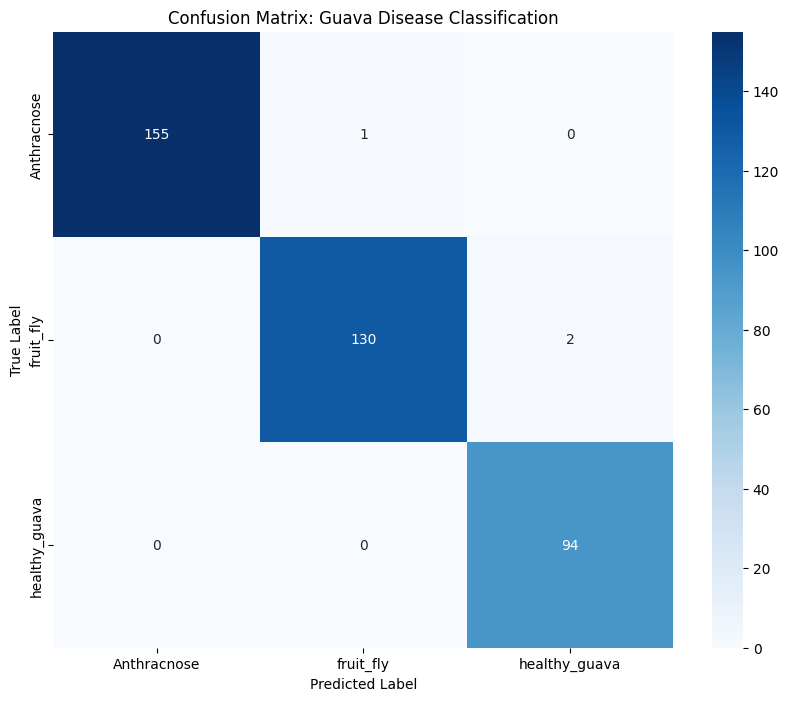

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Guava Disease Classification')
plt.show()

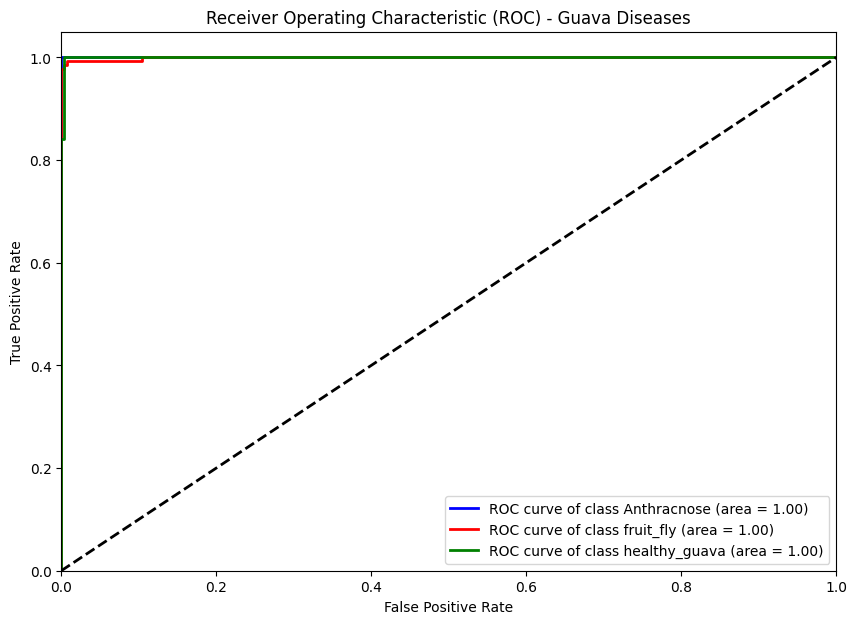

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

n_classes = len(class_names)
binarized_labels = label_binarize(all_labels, classes=[0, 1, 2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Guava Diseases')
plt.legend(loc="lower right")
plt.show()